## Dataset Preparation for Training Neural Networks on Images

This notebook demonstrates how to prepare an image dataset for training, validation, and testing. We cover splitting, preprocessing, data augmentation, and batching using PyTorch's `DataLoader`.

The modules below are required in all scripts that train and test neural networks on images.

In [1]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models, datasets
from PIL import Image 

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

### Randomly split a fileset into training, validation, and test sets: output lists of image names

In [ ]:
# Set the folder with the samples (images) that compose a dataset

orig_dir   = './images/corel'

# Set the desired image size for rescaling and maximum value for normalization

xsize      = 224 
ysize      = 224
nchannels  = 3 #porque sao coloridas
maxval     = 255. 

# Set the percentages of samples that will be used for training, validation and test. 

train_perc = 0.60 #nao e tao bom o ideal e treino pequeno, mas a base de dados nao e tao grande
valid_perc = 0.20
test_perc  = 0.20

# Create training, validation, and test sets.
# Expected filename format: "<class_number>_<name>.png" (e.g., "1_beach.png", "3_horse.png")

data = glob(orig_dir+"/*.png") # it returns a list of image filenames, lista com o nome dos arquivos que tao na pasta

##depois fazemos um shuffle dos arquivos e dividimos um certo numero pra treino/validacao e teste

num_train_samples = int(len(data)*train_perc)
num_valid_samples = int(len(data)*valid_perc)  
num_test_samples  = len(data) - num_train_samples - num_valid_samples 
np.random.shuffle(data) # randomly change the order of the filenames in data
trainset = data[:num_train_samples] 
validset = data[num_train_samples:num_train_samples+num_valid_samples]
testset  = data[num_train_samples+num_valid_samples:]

print(f"Total: {len(data)} images")
print(f"Training: {len(trainset)}, Validation: {len(validset)}, Test: {len(testset)}")

Total: 355 images
Training: 213, Validation: 71, Test: 71


### Create image datasets with some preprocessing: output a list of image tensors

In [ ]:
# Regular preprocessing transformation. The input is a PIL image, which after being resized, 
# it is converted into a tensor for normalization using the ImageNet mean and stdev parameters. 

# ImageNet statistics (used by pretrained models — we will revisit this in transfer learning)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


# PREPROCESSAMENTO DA IMAGEM
prep = transforms.Compose([
    transforms.Resize((224,224), interpolation=transforms.InterpolationMode.BILINEAR, 
                      max_size=None, antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)   # como muitas redes sao pre treinadas na IMAGENET aplicamos uma normalizacao na IMAGENET, pq a rede ja foi pre treinada com aquela normalizacao 
    # calcula a media e desvio padrao de tudo r,g,b e ai subtrai o valor dopixel da imagem nova dividido por 255, subtrai da media e divide pelo desvio 
])

# Data augmentation transformation (applied to training set only). By applying random
# affine transformations each time an image is loaded, we effectively increase the 
# diversity of training samples without saving augmented copies to disk.

# DATA AUGUMENTATION 
aug = transforms.Compose([
    transforms.Resize((300,300), interpolation=transforms.InterpolationMode.BILINEAR, 
                      max_size=None, antialias=True),
    transforms.RandomAffine(degrees=10, translate=(0.05,0.10), scale=(0.9,1.1), shear=(-2,2),
                            interpolation=transforms.InterpolationMode.BILINEAR, 
                            fill=0),
    transforms.CenterCrop(250),#depois da augmentation, damos um resize na imagem 
    transforms.Resize((224,224), interpolation=transforms.InterpolationMode.BILINEAR, 
                      max_size=None, antialias=True),
    transforms.ToTensor(),# como normalize opera com tensor mesmo sendo numpy antes preciso transformar pra tensor 
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)   
])

# Create an image dataset by applying one of the preprocessing transformations above.
# Inheriting from torch.utils.data.Dataset is the standard PyTorch pattern.

#dataset - lista com o nome dos arquivos que tao no disco
class ImageDataset(Dataset): # three mandatory methods: __init__, __len__, __getitem__
    def __init__(self, dataset, transform=None):
        self.dataset   = dataset
        # Extract class labels from filenames. 
        # Expected format: "<class_number>_<name>.png" (e.g., "1_beach.png")
        # We subtract 1 so that classes are 0-indexed.
        self.targets   = [int(str(x).split("/")[-1].split("_")[0])-1 for x in self.dataset] #processo esas listas, a classe 1 tem 10 exemplos por exemplo , numero da classe_numero da imagem
        self.transform = transform #pego a transformacao 
    def __len__(self): return len(self.dataset)        
    def __getitem__(self, ix): # returns the item at position ix #pego a imagem do dataset, pego a classe dessa imagem, abro a imagem com o pacote image.open  
        filename = self.dataset[ix]
        target   = self.targets[ix]
        image    = Image.open(filename) # It is a PIL image
        if (self.transform is not None): #se a transformacao nao for nenhuma, se ela é alguma ele aplica a transformacao que eu passei seja prep a chamada da classe ou aug
            image = self.transform(image)
        else: # fallback: reshape as tensor (no normalization — avoid using this in practice) e se nao tiver nenhuma transformacao ai so converte a imagem de numpy pra tensor
            image = torch.from_numpy(np.array(image)).permute(2,0,1).float()                  
        return(image,target)

        # no tensor tem que tem numero de canais, e no numpy e largura e altura 

### Visualize selected images

Number of images: 213
Images are 224x224x3


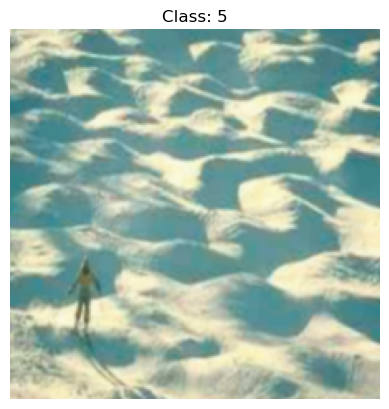

In [ ]:
# Visualize an image from the training set
#pra visualizar a imagem tenho que fazer tudo de volta
datatensor = ImageDataset(trainset, aug) #esse objeto é um vetor de tensores , com 2 vetores tensor e target 
print("Number of images:", len(datatensor))
image, target = datatensor[0] # it executes __getitem__
nchannels = image.shape[0]
height    = image.shape[1]
width     = image.shape[2]
print("Images are {}x{}x{}".format(width, height, nchannels))

# Undo the ImageNet normalization for visualization
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
image_vis = (image * std + mean).clamp(0, 1)  # exact inverse
image_vis = image_vis.permute(1, 2, 0).numpy()

plt.imshow(image_vis)
plt.title(f"Class: {target + 1}")
plt.axis('off')
plt.show()

#pytorch sao ponteiros de funcoes, pra deixar rapido e preciso guardar o vetor do disco guardar na memoria e chamar ele novamente 

### Create functions that return random batches from the image lists in the training, validation, and test sets

In [ ]:
#para treinar o modelo por batchs 

batchsize = 32

def GetBatches(dataset, batchsize, transformation):
    datatensor = ImageDataset(dataset, transformation) 
    dataloader = DataLoader(datatensor, batch_size=batchsize, shuffle=True)
    return(dataloader)

# Use 'aug' for training (data augmentation) and 'prep' for validation/test (standard preprocessing).
# Note: avoid using transform=None, as the fallback skips normalization and produces inconsistent data.
# o dataload de treino so que tem augmentation so fazemos no treino 
trainload = GetBatches(trainset, batchsize, aug)  
validload = GetBatches(validset, batchsize, prep)
testload  = GetBatches(testset, batchsize, prep)

### When `GetBatches` is called on the training set, data augmentation is applied on-the-fly in `ImageDataset.__getitem__`, and `DataLoader` shuffles the image tensors and divides them into batches. There is no need to save the augmented images — but more epochs will be required for the model to see enough variations of each training sample.

### Inspect a batch to see what the model receives

In [ ]:
# Fetch one batch from the training loader
images, targets = next(iter(trainload)) #se tiver um bug vai dar problema aq 
print(f"Batch of images: shape={images.shape}, dtype={images.dtype}")
print(f"  -> {images.shape[0]} images, {images.shape[1]} channels, {images.shape[2]}x{images.shape[3]} pixels")
print(f"Batch of targets: shape={targets.shape}, dtype={targets.dtype}")
print(f"  -> class labels: {targets[:8]}...")

#se isso falhar e pq tem alguma coisa errada no dataset

Batch of images: shape=torch.Size([32, 3, 224, 224]), dtype=torch.float32
  -> 32 images, 3 channels, 224x224 pixels
Batch of targets: shape=torch.Size([32]), dtype=torch.int64
  -> class labels: tensor([0, 4, 0, 2, 4, 0, 1, 0])...
